In [17]:
# =========================
# 1. MONTAR DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. LIBRERÍAS
# =========================
import pandas as pd
import numpy as np
import glob
import os

# =========================
# 3. PATH
# =========================
path = '/content/drive/MyDrive/Colab Notebooks/Financial Summary/*.xlsx'
files = glob.glob(path)

print(f"Archivos encontrados: {len(files)}")

panel_list = []

# =========================
# 4. FUNCIÓN ROBUSTA (ANTI-BASURA)
# =========================
def extract(df, keyword, dates):

    candidates = df[df[0].astype(str).str.contains(keyword, case=False, na=False)]

    if candidates.empty:
        return [None]*len(dates)

    best_row = None
    max_numeric = 0

    for i in range(len(candidates)):
        row = candidates.iloc[i, 1:]

        numeric_values = pd.to_numeric(row, errors='coerce')
        count_numeric = numeric_values.notna().sum()

        if count_numeric > max_numeric:
            max_numeric = count_numeric
            best_row = numeric_values

    if best_row is not None and max_numeric > 5:
        return best_row.values
    else:
        return [None]*len(dates)

# =========================
# 5. LOOP PRINCIPAL
# =========================
for file in files:

    try:
        empresa = os.path.basename(file).replace('5yearsFS.xlsx','')

        df = pd.read_excel(file, header=None)

        # Buscar fila de fechas
        date_row_idx = df[df[0] == 'Field Name'].index

        if len(date_row_idx) == 0:
            print(f"⚠️ No se encontró estructura en {empresa}")
            continue

        date_row_idx = date_row_idx[0]
        dates = df.iloc[date_row_idx, 1:].values

        # =========================
        # VARIABLES
        # =========================
        temp = pd.DataFrame({
            'Ticker': empresa,
            'Date': dates,
            'Revenue': extract(df, 'Revenue', dates),
            'EBITDA': extract(df, 'Operating Profit before Non-Recurring Income/Expense|EBITDA', dates),
            'NetIncome': extract(df, 'Net Income|Income Available', dates),
            'TotalAssets': extract(df, 'Total Assets', dates),
            'CommonEquity': extract(df, 'Total Equity', dates),
            'EPS': extract(df, 'EPS', dates)
        })

        panel_list.append(temp)

        print(f"✅ {empresa}")

    except Exception as e:
        print(f"❌ Error en {file}: {e}")

# =========================
# 6. UNIR DATA
# =========================
panel_df = pd.concat(panel_list)

# =========================
# 7. LIMPIEZA
# =========================
panel_df['Date'] = pd.to_datetime(panel_df['Date'], dayfirst=True, errors='coerce')

cols = panel_df.columns.drop(['Ticker', 'Date'])
for col in cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors='coerce')

panel_df = panel_df.dropna(subset=['Date'])

panel_df = panel_df.sort_values(['Ticker', 'Date'])

# =========================
# 8. RATIOS FINANCIOS 🔥
# =========================
panel_df['ROA'] = panel_df['NetIncome'] / panel_df['TotalAssets']
panel_df['ROE'] = panel_df['NetIncome'] / panel_df['CommonEquity']
panel_df['LogAssets'] = np.log(panel_df['TotalAssets'])

# =========================
# 9. RESULTADO
# =========================
print("\nShape final:", panel_df.shape)
print("\nColumnas:", panel_df.columns)
panel_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos encontrados: 13
✅ NVDA
✅ RVIN
✅ LRCX
✅ WFC
✅ XOM
✅ BAC
✅ TSM
✅ VLO
✅ MS
✅ SAN
✅ SHEL
✅ JPM
✅ CITI

Shape final: (223, 11)

Columnas: Index(['Ticker', 'Date', 'Revenue', 'EBITDA', 'NetIncome', 'TotalAssets',
       'CommonEquity', 'EPS', 'ROA', 'ROE', 'LogAssets'],
      dtype='object')


,Ticker,Date,Revenue,EBITDA,NetIncome,TotalAssets,CommonEquity,EPS,ROA,ROE,LogAssets
0,BAC,2021-12-30,9994.0,7827.0,12.38,3169495.0,198844.0,0.82,0.000004,0.000062,14.969083
1,BAC,2022-03-30,10683.0,7985.0,12.10,3238223.0,195495.0,0.80,0.000004,0.000062,14.990535
2,BAC,2022-06-29,9673.0,7390.0,10.76,3111606.0,197996.0,0.73,0.000003,0.000054,14.950650
3,BAC,2022-09-29,9523.0,8808.0,10.58,3072953.0,198402.0,0.81,0.000003,0.000053,14.938150
4,BAC,2022-12-30,9129.0,7986.0,10.61,3051375.0,202075.0,0.85,0.000003,0.000053,14.931103


In [18]:
# =========================
# 10. GUARDAR CSV
# =========================
output_path = '/content/drive/MyDrive/Colab Notebooks/panel_data_final.csv'

panel_df.to_csv(output_path, index=False)

print(f"\n✅ CSV guardado en:\n{output_path}")


✅ CSV guardado en:
/content/drive/MyDrive/Colab Notebooks/panel_data_final.csv


Estadísticas descriptivas del panel de datos

In [20]:
panel_df.groupby('Ticker').mean()

,Date,Revenue,EBITDA,NetIncome,TotalAssets,CommonEquity,EPS,ROA,ROE,LogAssets
Ticker,,,,,,,,,,
BAC,2023-12-29 15:31:45.882352896,10178.000000,8811.647059,10.331176,3.236375e+06,215610.235294,0.826471,0.000003,0.000048,14.989323
CITI,2023-12-29 15:31:45.882352896,5682.823529,4624.764706,6.713529,2.449355e+06,183311.000000,1.500000,0.000003,0.000037,14.710452
JPM,2023-12-29 15:31:45.882352896,18035.529412,15671.705882,16.588824,4.041618e+06,261089.352941,4.198824,0.000004,0.000064,15.209805
LRCX,2023-09-25 22:44:12.631578880,4358.457368,1360.982105,61.662632,1.874761e+04,62.965263,0.892105,0.003347,1.003289,9.834468
MS,2023-12-29 15:31:45.882352896,5734.235294,4261.647059,12.508125,1.235601e+06,80466.588235,1.852353,0.000010,0.000155,14.025261
NVDA,2024-01-27 00:00:00.000000000,25998.470588,15088.294118,76.751176,8.425259e+04,26.475294,0.548824,0.000937,6.203881,11.197564
RVIN,2023-12-29 15:31:45.882352896,970.764706,-1317.647059,-61.464000,1.713271e+04,45.915882,-1.945882,-0.003715,-3.098623,9.740333
SAN,2023-12-29 15:31:45.882352896,3590.000000,4676.941176,11.411765,1.780811e+06,85079.764706,0.171176,0.000006,0.000134,14.391839
SHEL,2023-12-29 15:31:45.882352896,78494.823529,10306.882353,13.375294,4.074257e+05,43.304706,0.913529,0.000032,0.308174,12.916138


Visualización del panel

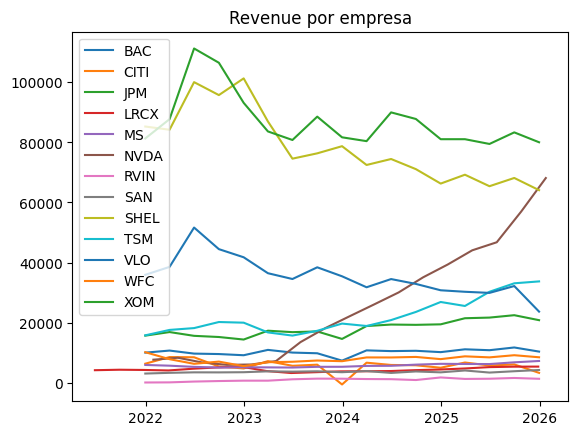

In [21]:
import matplotlib.pyplot as plt

for ticker in panel_df['Ticker'].unique():
    subset = panel_df[panel_df['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Revenue'], label=ticker)

plt.legend()
plt.title('Revenue por empresa')
plt.show()

In [22]:
panel_df['Revenue_Growth'] = panel_df.groupby('Ticker')['Revenue'].pct_change()